In [69]:
import numpy as np
import matplotlib.pyplot as plt

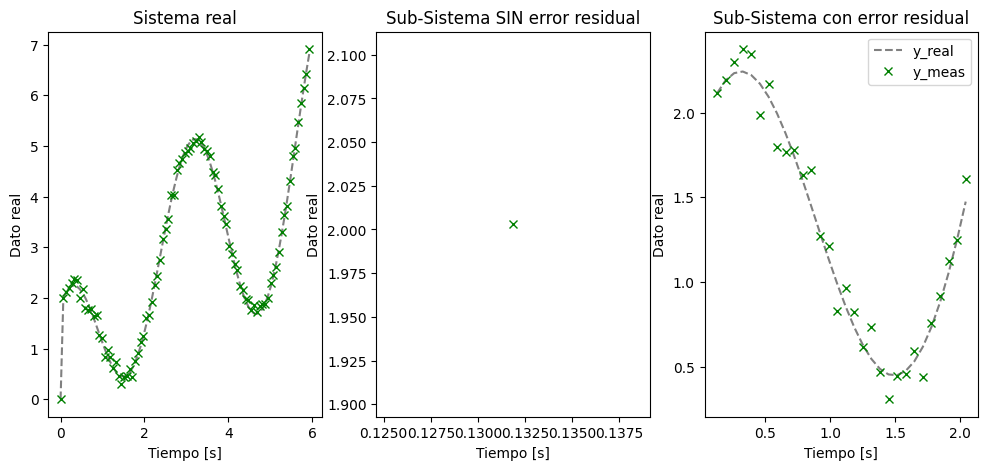

In [70]:
# Primero simulemos el sistema "real"
M = 91
std = [0., 0.1] # Los primeros 3 tienen menos error
delta = 6/M
y = np.zeros((M,1))
y_meas = np.zeros((M,1))

# PHI - GAMMA
x = [0.9967, 0.9556, 2.0030] # Coeficientes de las h (en este caso, y-u)

t = np.arange(M) * delta

for j in range(1,M):
    y[j] = x[0] * t[j-1] + x[1] * np.sin(t[j-1]) + x[2] * np.cos(2*t[j-1])
    if j <= 3:
        y_meas[j] = y[j] + np.random.normal(0, std[0])
    else:
        y_meas[j] = y[j] + np.random.normal(0, std[1])

plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.title("Sistema real")
plt.xlabel("Tiempo [s]")
plt.ylabel("Dato real")
plt.plot(t, y, '--', c='gray', label='y_real')
plt.plot(t, y_meas, 'x', c='green', label='y_meas')

t = t[1:32]

n_perfectas = 1
y_meas_1 = y_meas[1 + n_perfectas:32]
y_meas_2 = y_meas[1:1 + n_perfectas]

plt.subplot(1,3,2)
plt.title("Sub-Sistema SIN error residual")
plt.xlabel("Tiempo [s]")
plt.ylabel("Dato real")
plt.plot(t[1:1 + n_perfectas], y[1:1 + n_perfectas], '--', c='gray', label='y_real')
plt.plot(t[1:1 + n_perfectas], y_meas_2, 'x', c='green', label='y_meas')

plt.subplot(1,3,3)
plt.title("Sub-Sistema con error residual")
plt.xlabel("Tiempo [s]")
plt.ylabel("Dato real")
plt.plot(t[n_perfectas:], y[1 + n_perfectas:32], '--', c='gray', label='y_real')
plt.plot(t[n_perfectas:], y_meas_1, 'x', c='green', label='y_meas')
plt.legend()
plt.show()

In [72]:
W = np.ones_like(y_meas_1[1:])
W = np.eye(W.shape[0])

h1 = t[n_perfectas:].copy().reshape(-1,1)[:-1]
h2 = np.sin(t[n_perfectas:]).reshape(-1,1)[:-1]
h3 = np.cos(2*t[n_perfectas:]).reshape(-1,1)[:-1]
H1 = np.hstack((h1,h2,h3))
#H1 = (H1 - H1.mean(axis=0)) / H1.std(axis=0)

h1 = t[:1+n_perfectas].copy().reshape(-1,1)[:-1]
h2 = np.sin(t[:1+n_perfectas]).reshape(-1,1)[:-1]
h3 = np.cos(2*t[:1+n_perfectas]).reshape(-1,1)[:-1]
H2 = np.hstack((h1,h2,h3))
#H2 = (H2 - H2.mean(axis=0)) / H2.std(axis=0)

print(W.shape, H1.shape, H2.shape)

comp1 = np.linalg.pinv(H1.T @ W @ H1)

x_lsqt = comp1 @ H1.T @ W @ y_meas_1[1:]
K = comp1 @ H2.T @ np.linalg.pinv(H2 @ comp1 @ H2.T)
x_est = x_lsqt + K @ (y_meas_2 - H2 @ x_lsqt)

y_est = np.zeros((y_meas_1.shape[0],1))
for j in range(1,y_meas_1.shape[0]):
    y_est[j] = x_est[0] * t[j-1] + x_est[1] * np.sin(t[j-1]) + x_est[2] * np.cos(2*t[j-1])


print("X_real:", x)
print("X_lsqt:", x_lsqt.flatten())
print("X_est:", x_est.flatten())


(29, 29) (29, 3) (1, 3)
X_real: [0.9967, 0.9556, 2.003]
X_lsqt: [1.04621795 0.91271804 2.02624061]
X_est: [0.9032055  1.03943506 1.89138447]
